#### Investigation Question 5

##### How do content ratings correlate with specific genres?

###### Objective

The objective of this analysis is to examine the relationship between content ratings and genres available on Netflix. Understanding how maturity ratings are distributed across different genres helps identify the intended audience for various types of content.

Since each title may belong to multiple genres, the `Type` column will be separated into individual genres before analyzing the relationship with content ratings.

This analysis will reveal whether certain genres are predominantly associated with family-friendly ratings or mature audience classifications.

##### Methodology

The analysis is performed using the following steps:

1. Select the `Rating` and `Type` columns.
2. Remove records containing missing values.
3. Split the `Type` column into individual genres.
4. Expand the genres using the `explode()` function.
5. Create a cross-tabulation between genres and ratings.
6. Calculate percentage distributions where necessary.
7. Visualize the relationship using a heatmap.
8. Identify dominant rating patterns within each genre.
9. Interpret the findings and discuss their business implications.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("../data/raw/Netflix Dataset.csv")

In [8]:
# Heatmap helper function
def plot_heatmap(data, title, cmap="YlGnBu", figsize=(14,10)):
    """
    Plot a heatmap for a contingency table.
    """

    plt.figure(figsize=figsize)

    sns.heatmap(
        data,
        annot=True,
        fmt=".1f",
        cmap=cmap,
        linewidths=0.5
    )

    plt.title(title, fontsize=16, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [18]:
# Prepare Data for Rating vs Genre Analysis

rating_genre = df[["Rating", "Type"]].dropna().copy()

rating_genre["Type"] = rating_genre["Type"].str.split(",")

rating_genre = (
    rating_genre
    .explode("Type")
    .reset_index(drop=True)   # <-- Important
)

rating_genre["Type"] = rating_genre["Type"].str.strip()

rating_genre.head()

,Rating,Type
0,TV-MA,International TV Shows
1,TV-MA,TV Dramas
2,TV-MA,TV Sci-Fi & Fantasy
3,TV-MA,Dramas
4,TV-MA,International Movies


In [6]:
rating_genre_table = pd.crosstab(
    rating_genre["Type"],
    rating_genre["Rating"]
)

rating_genre_table

Rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
Type,,,,,,,,,,,,,,
Action & Adventure,1,0,9,23,118,171,187,0,181,28,0,0,1,2
Anime Features,0,0,0,5,4,0,14,0,13,17,0,4,0,0
Anime Series,0,0,0,0,0,0,59,0,50,15,1,22,0,0
British TV Shows,0,0,2,0,0,0,43,15,96,54,17,5,0,0
Children & Family Movies,31,0,0,166,11,0,17,47,0,73,98,84,5,0
Classic & Cult TV,0,0,0,0,0,0,11,1,7,6,1,1,0,0
Classic Movies,7,0,3,13,9,27,21,1,11,11,0,0,0,0
Comedies,11,2,16,125,139,153,424,27,375,146,17,31,4,2
Crime TV Shows,0,0,1,0,0,0,104,1,314,4,0,3,0,0


In [7]:
rating_genre_percentage = (
    pd.crosstab(
        rating_genre["Type"],
        rating_genre["Rating"],
        normalize="index"
    ) * 100
).round(2)

rating_genre_percentage

Rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
Type,,,,,,,,,,,,,,
Action & Adventure,0.14,0.00,1.25,3.19,16.37,23.72,25.94,0.00,25.10,3.88,0.00,0.00,0.14,0.28
Anime Features,0.00,0.00,0.00,8.77,7.02,0.00,24.56,0.00,22.81,29.82,0.00,7.02,0.00,0.00
Anime Series,0.00,0.00,0.00,0.00,0.00,0.00,40.14,0.00,34.01,10.20,0.68,14.97,0.00,0.00
British TV Shows,0.00,0.00,0.86,0.00,0.00,0.00,18.53,6.47,41.38,23.28,7.33,2.16,0.00,0.00
Children & Family Movies,5.83,0.00,0.00,31.20,2.07,0.00,3.20,8.83,0.00,13.72,18.42,15.79,0.94,0.00
Classic & Cult TV,0.00,0.00,0.00,0.00,0.00,0.00,40.74,3.70,25.93,22.22,3.70,3.70,0.00,0.00
Classic Movies,6.80,0.00,2.91,12.62,8.74,26.21,20.39,0.97,10.68,10.68,0.00,0.00,0.00,0.00
Comedies,0.75,0.14,1.09,8.49,9.44,10.39,28.80,1.83,25.48,9.92,1.15,2.11,0.27,0.14
Crime TV Shows,0.00,0.00,0.23,0.00,0.00,0.00,24.36,0.23,73.54,0.94,0.00,0.70,0.00,0.00


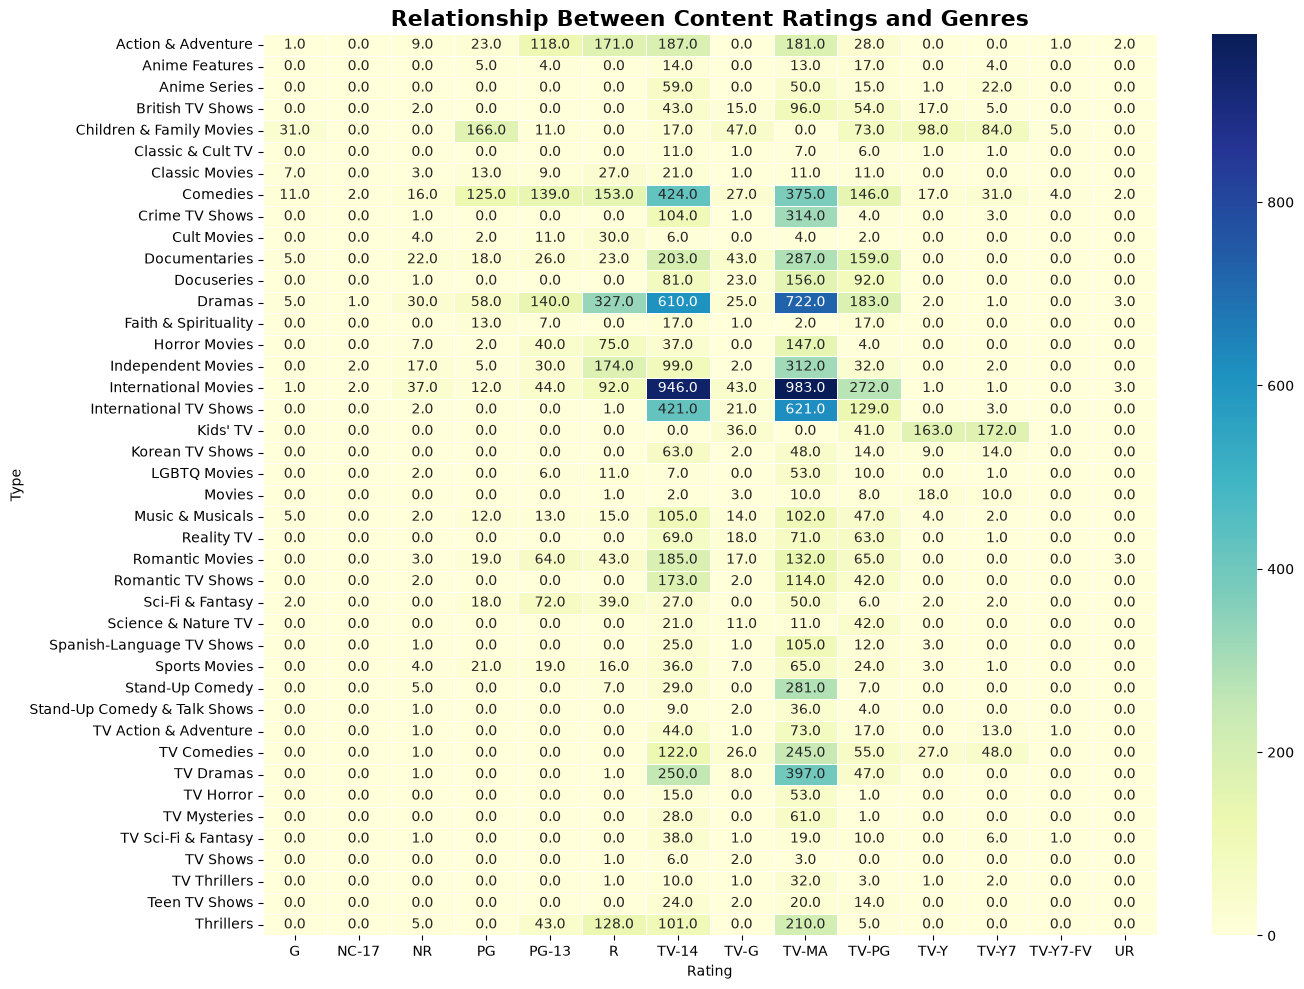

In [14]:
plot_heatmap(
    rating_genre_table,
    title="Relationship Between Content Ratings and Genres"
)

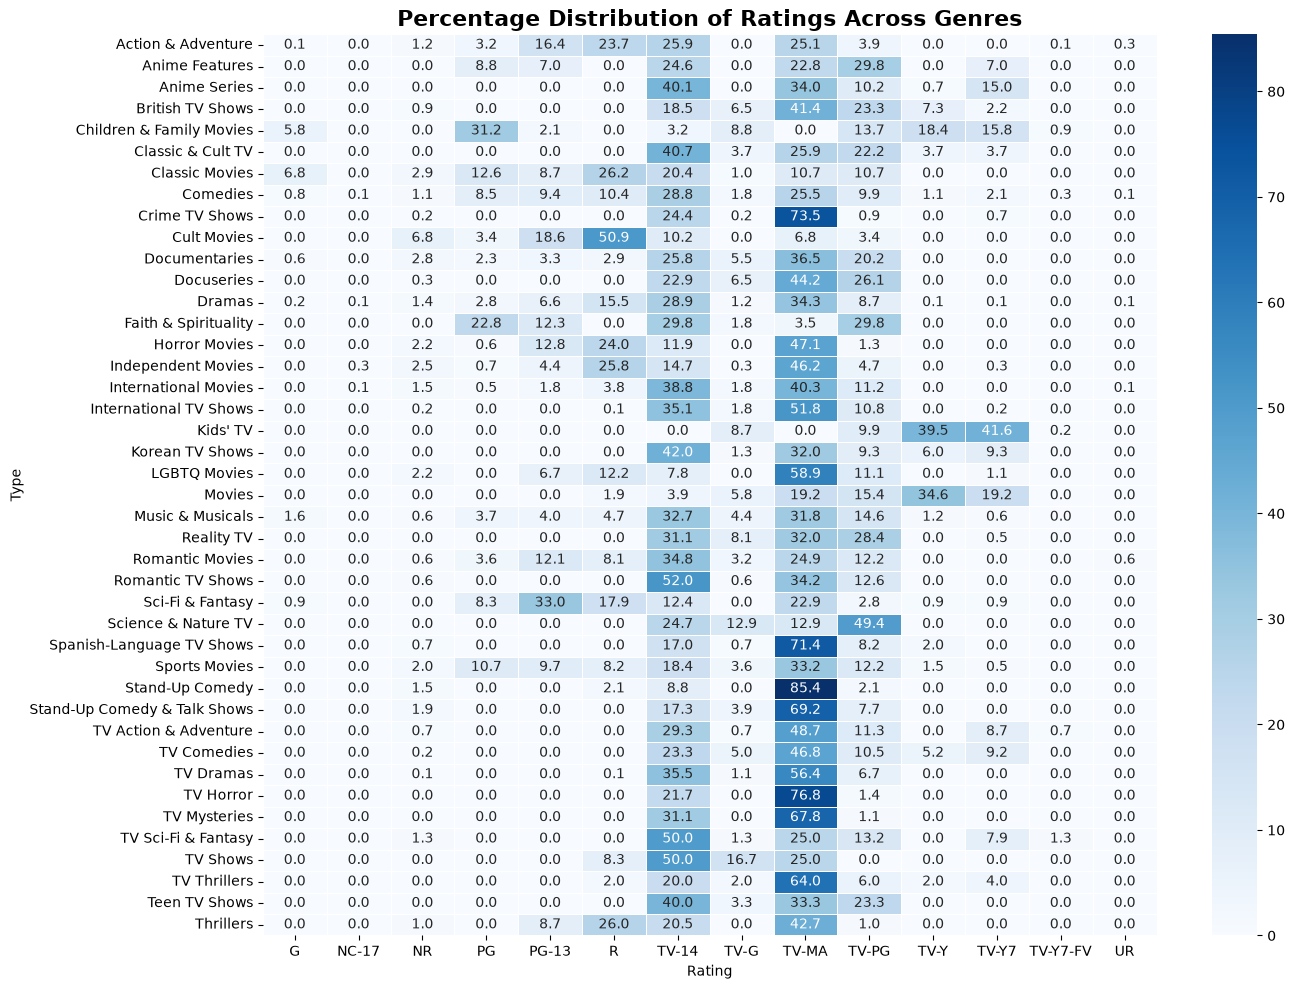

In [15]:
plot_heatmap(
    rating_genre_percentage,
    title="Percentage Distribution of Ratings Across Genres",
    cmap="Blues"
)

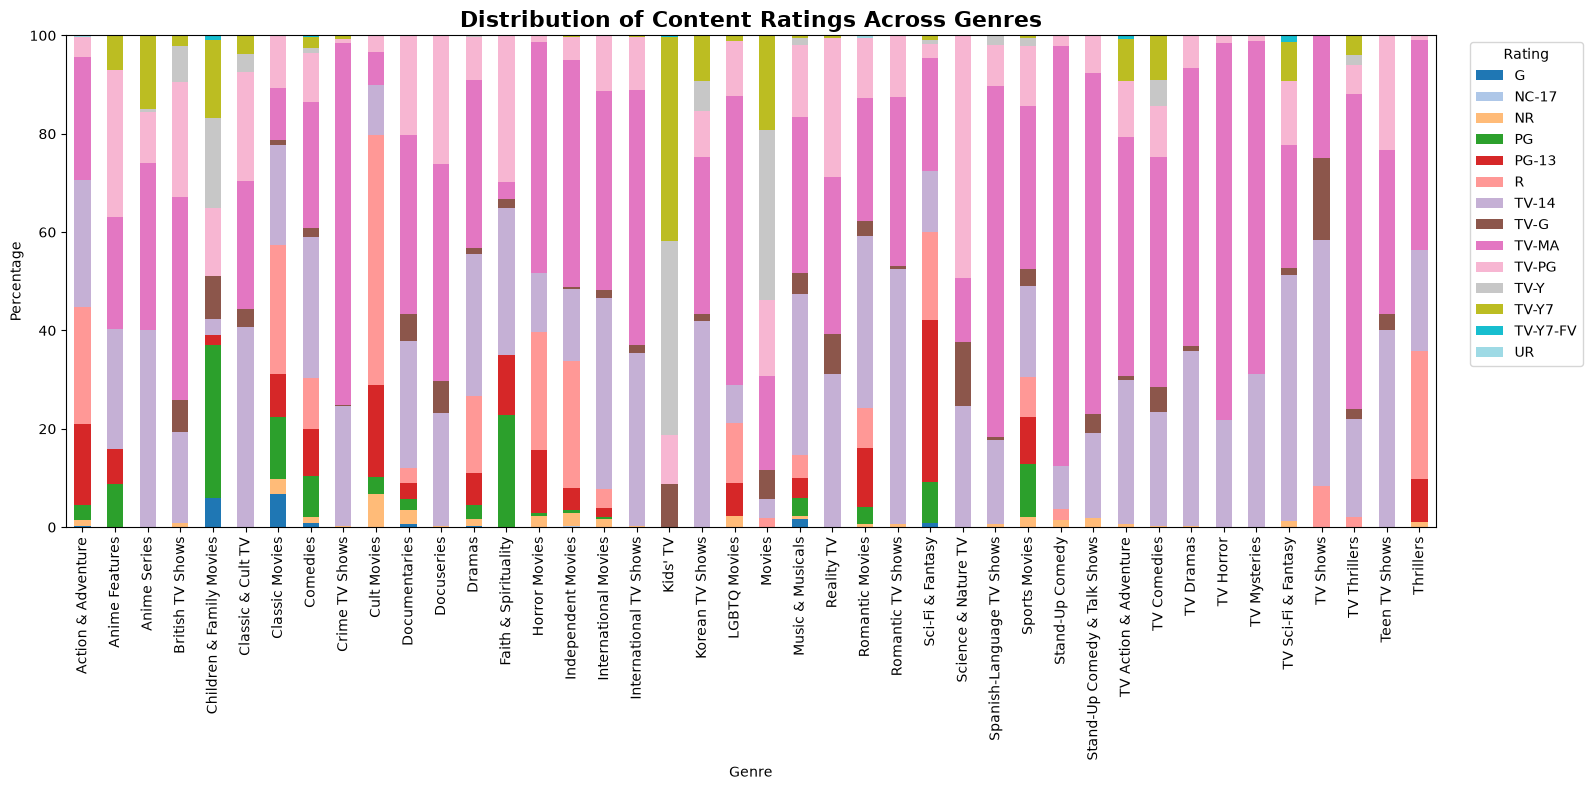

In [16]:
rating_genre_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(16,8),
    colormap="tab20"
)

plt.title(
    "Distribution of Content Ratings Across Genres",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Genre")
plt.ylabel("Percentage")

plt.legend(
    title="Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

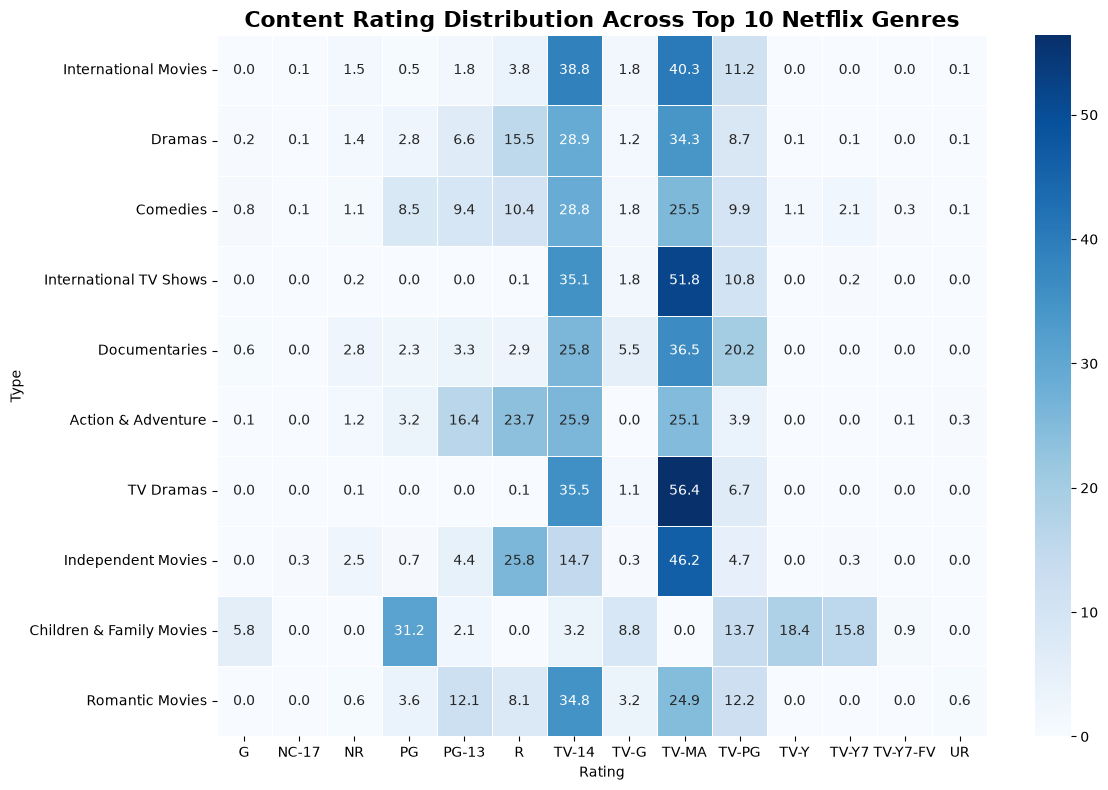

In [20]:
genre_counts = (
    df["Type"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

genre_counts.head(10)

top_genres = genre_counts.head(10).index

rating_genre_percentage_top10 = rating_genre_percentage.loc[top_genres]

plot_heatmap(
    rating_genre_percentage_top10,
    title="Content Rating Distribution Across Top 10 Netflix Genres",
    cmap="Blues",
    figsize=(12, 8)
)

In [21]:
dominant_rating = rating_genre_percentage.idxmax(axis=1)

dominant_percentage = rating_genre_percentage.max(axis=1)

dominant_rating_summary = pd.DataFrame({
    "Dominant Rating": dominant_rating,
    "Percentage (%)": dominant_percentage
})

dominant_rating_summary.sort_values(
    by="Percentage (%)",
    ascending=False
).head(15)

,Dominant Rating,Percentage (%)
Type,,
Stand-Up Comedy,TV-MA,85.41
TV Horror,TV-MA,76.81
Crime TV Shows,TV-MA,73.54
Spanish-Language TV Shows,TV-MA,71.43
Stand-Up Comedy & Talk Shows,TV-MA,69.23
TV Mysteries,TV-MA,67.78
TV Thrillers,TV-MA,64.00
LGBTQ Movies,TV-MA,58.89
TV Dramas,TV-MA,56.39


#### Key Insights

- **TV-MA** and **TV-14** are the dominant maturity ratings across most Netflix genres, indicating that the platform primarily targets mature and young adult audiences.

- **International Movies**, the largest genre in the catalog, are predominantly classified as **TV-MA (40.3%)** and **TV-14 (38.8%)**, suggesting that international content on Netflix largely caters to mature viewers.

- **Dramas** exhibit a similar distribution, with **34.3%** of titles rated **TV-MA** and **28.9%** rated **TV-14**, reinforcing Netflix's emphasis on mature, story-driven content.

- **International TV Shows** and **TV Dramas** show the strongest concentration of mature ratings, with **51.8%** and **56.4%** of their titles rated **TV-MA**, respectively. This indicates that serialized content is generally produced for adult audiences.

- **Independent Movies** are also predominantly targeted toward mature viewers, with **46.2%** carrying a **TV-MA** rating and **25.8%** rated **R**, reflecting the greater creative freedom often associated with independent productions.

- **Children & Family Movies** display a distinctly different rating distribution. The majority of titles fall under **PG (31.2%)**, **TV-Y (18.4%)**, **TV-Y7 (15.8%)**, and **TV-PG (13.7%)**, confirming that this genre is primarily designed for children and family audiences.

- **Documentaries** exhibit a balanced rating profile, although **TV-MA (36.5%)** and **TV-14 (25.8%)** remain the most common ratings, indicating that many documentaries address mature or complex subject matter.

- **Action & Adventure** content spans a broader range of maturity levels, with notable proportions of **TV-14 (25.9%)**, **TV-MA (25.1%)**, and **R (23.7%)**, suggesting that action-oriented content is distributed across both teenage and adult audiences.

- Genres such as **Romantic Movies**, **Comedies**, and **Thrillers** are primarily concentrated within **TV-14** and **TV-MA**, demonstrating Netflix's preference for producing entertainment aimed at adolescents and adults rather than younger viewers.

- Family-oriented ratings such as **G**, **TV-Y**, and **TV-Y7** appear almost exclusively in children's genres, while they are nearly absent from drama, thriller, crime, and international content.

#### Business Interpretation

The relationship between content ratings and genres reveals Netflix's deliberate audience segmentation strategy. Mature audience ratings (**TV-MA** and **TV-14**) dominate the majority of genres, indicating that Netflix's catalog is primarily designed to serve teenagers and adults who represent a significant portion of the platform's subscriber base.

International content, dramas, crime series, and independent films consistently receive mature ratings, suggesting that Netflix prioritizes realistic storytelling, complex narratives, and culturally diverse productions aimed at older viewers. This strategy aligns with the platform's continued investment in original productions and internationally produced content that appeals to global adult audiences.

In contrast, children's programming maintains an entirely different rating distribution, concentrating around **G**, **PG**, **TV-Y**, and **TV-Y7** classifications. This separation demonstrates Netflix's ability to curate age-appropriate content for younger viewers while maintaining a distinct portfolio for mature audiences.

The analysis also highlights that genres such as Action & Adventure and Documentaries cover a wider range of ratings, enabling Netflix to reach multiple demographic groups within a single genre. This diversified rating strategy allows the platform to maximize audience reach while maintaining clear content classifications for viewers.

#### Conclusion

The bivariate analysis demonstrates a strong relationship between content genres and maturity ratings within Netflix's catalog. Most genres are dominated by **TV-MA** and **TV-14** classifications, confirming that Netflix primarily focuses on content intended for mature and young adult audiences.

Genres associated with dramatic storytelling, international productions, crime, and independent filmmaking consistently exhibit higher proportions of mature ratings, whereas children's and family-oriented genres remain concentrated within age-appropriate classifications such as **G**, **PG**, **TV-Y**, and **TV-Y7**.

Overall, the findings indicate that Netflix effectively aligns content ratings with genre characteristics, enabling the platform to cater to diverse audience segments while maintaining appropriate content classification standards. This relationship between genre and maturity rating provides valuable insight into Netflix's content acquisition strategy and audience targeting approach.

### Investigation Question 6

#### Are certain genres concentrated in specific countries?

##### Objective

The objective of this analysis is to investigate the relationship between countries and content genres available on Netflix. Since a single title may belong to multiple countries and multiple genres, both variables contain comma-separated values that require preprocessing before analysis.

By examining the distribution of genres across different countries, this analysis aims to identify regional content specializations, understand geographical production trends, and explore how Netflix's content portfolio varies across major production markets.

#### Methodology

The analysis is performed using the following steps:

1. Select the `Country` and `Type` columns.
2. Remove records containing missing values.
3. Split multiple countries into individual entries.
4. Split multiple genres into individual entries.
5. Expand both columns using the `explode()` function.
6. Create a cross-tabulation between countries and genres.
7. Calculate percentage distributions where appropriate.
8. Visualize the relationship using heatmaps.
9. Identify dominant genres within major content-producing countries.
10. Interpret the findings and discuss their business implications.

In [24]:
# Prepare Country vs Genre Data

country_genre = df[["Country", "Type"]].dropna().copy()

# Split multiple values
country_genre["Country"] = country_genre["Country"].str.split(",")
country_genre["Type"] = country_genre["Type"].str.split(",")

# Explode both columns
country_genre = country_genre.explode("Country")
country_genre = country_genre.explode("Type")

# Remove extra spaces
country_genre["Country"] = country_genre["Country"].str.strip()
country_genre["Type"] = country_genre["Type"].str.strip()

# ⭐ IMPORTANT: Reset the index
country_genre = country_genre.reset_index(drop=True)

country_genre.head()

,Country,Type
0,Brazil,International TV Shows
1,Brazil,TV Dramas
2,Brazil,TV Sci-Fi & Fantasy
3,Mexico,Dramas
4,Mexico,International Movies


In [25]:
country_genre_table = pd.crosstab(
    country_genre["Country"],
    country_genre["Type"]
)

country_genre_table

Type,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
Country,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Angola,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vatican City,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Venezuela,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Vietnam,2,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,1


In [26]:
country_genre_percentage = (
    pd.crosstab(
        country_genre["Country"],
        country_genre["Type"],
        normalize="index"
    ) * 100
).round(2)

country_genre_percentage

Type,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
Country,,,,,,,,,,,,,,,,,,,,,
,0.00,0.0,0.0,0.0,0.00,0.0,12.50,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Afghanistan,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Albania,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Algeria,0.00,0.0,0.0,0.0,0.00,0.0,20.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Angola,50.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vatican City,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Venezuela,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
Vietnam,13.33,0.0,0.0,0.0,0.00,0.0,0.00,13.33,0.0,0.0,...,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,6.67


In [30]:
# Country vs Genre Cross-tabulation

country_genre_table = pd.crosstab(
    index=country_genre["Country"],
    columns=country_genre["Type"]
)

country_genre_table

Type,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
Country,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Angola,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vatican City,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Venezuela,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Vietnam,2,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,1


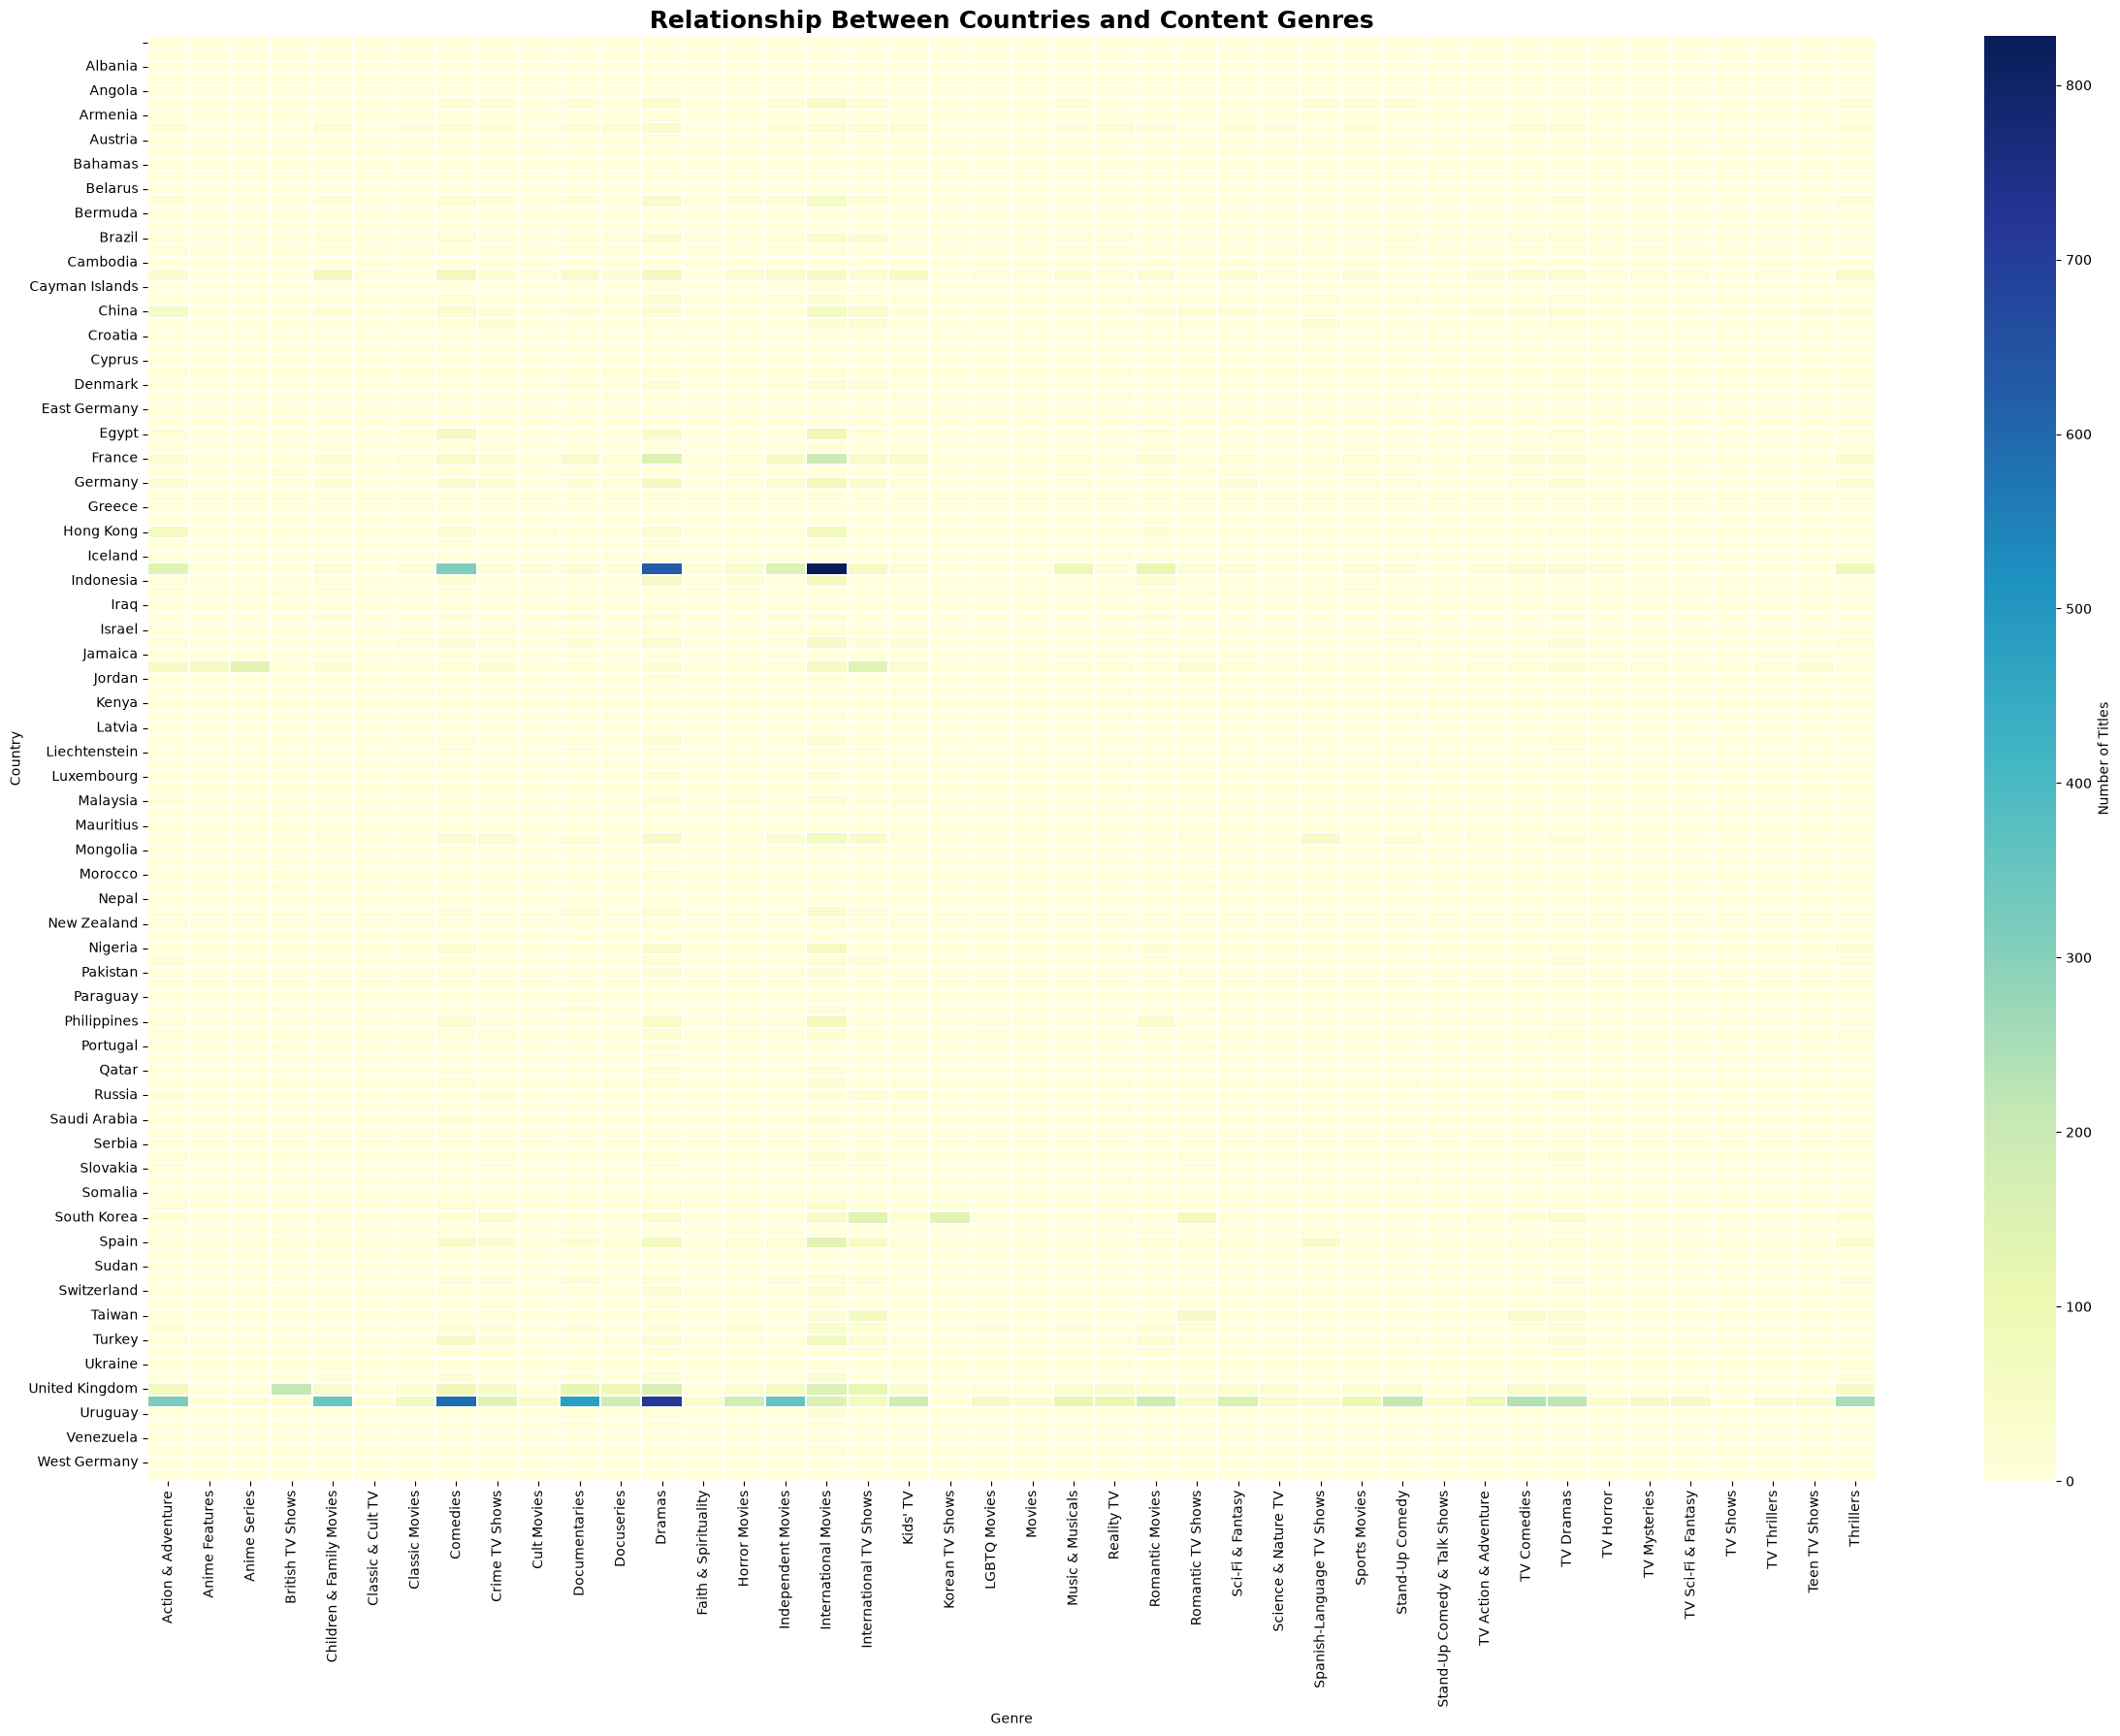

In [31]:
# Overall Country vs Genre Heatmap

plt.figure(figsize=(24, 18))

sns.heatmap(
    country_genre_table,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Number of Titles"}
)

plt.title(
    "Relationship Between Countries and Content Genres",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Genre")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [32]:
country_genre_percentage = (
    pd.crosstab(
        country_genre["Country"],
        country_genre["Type"],
        normalize="index"
    ) * 100
).round(2)

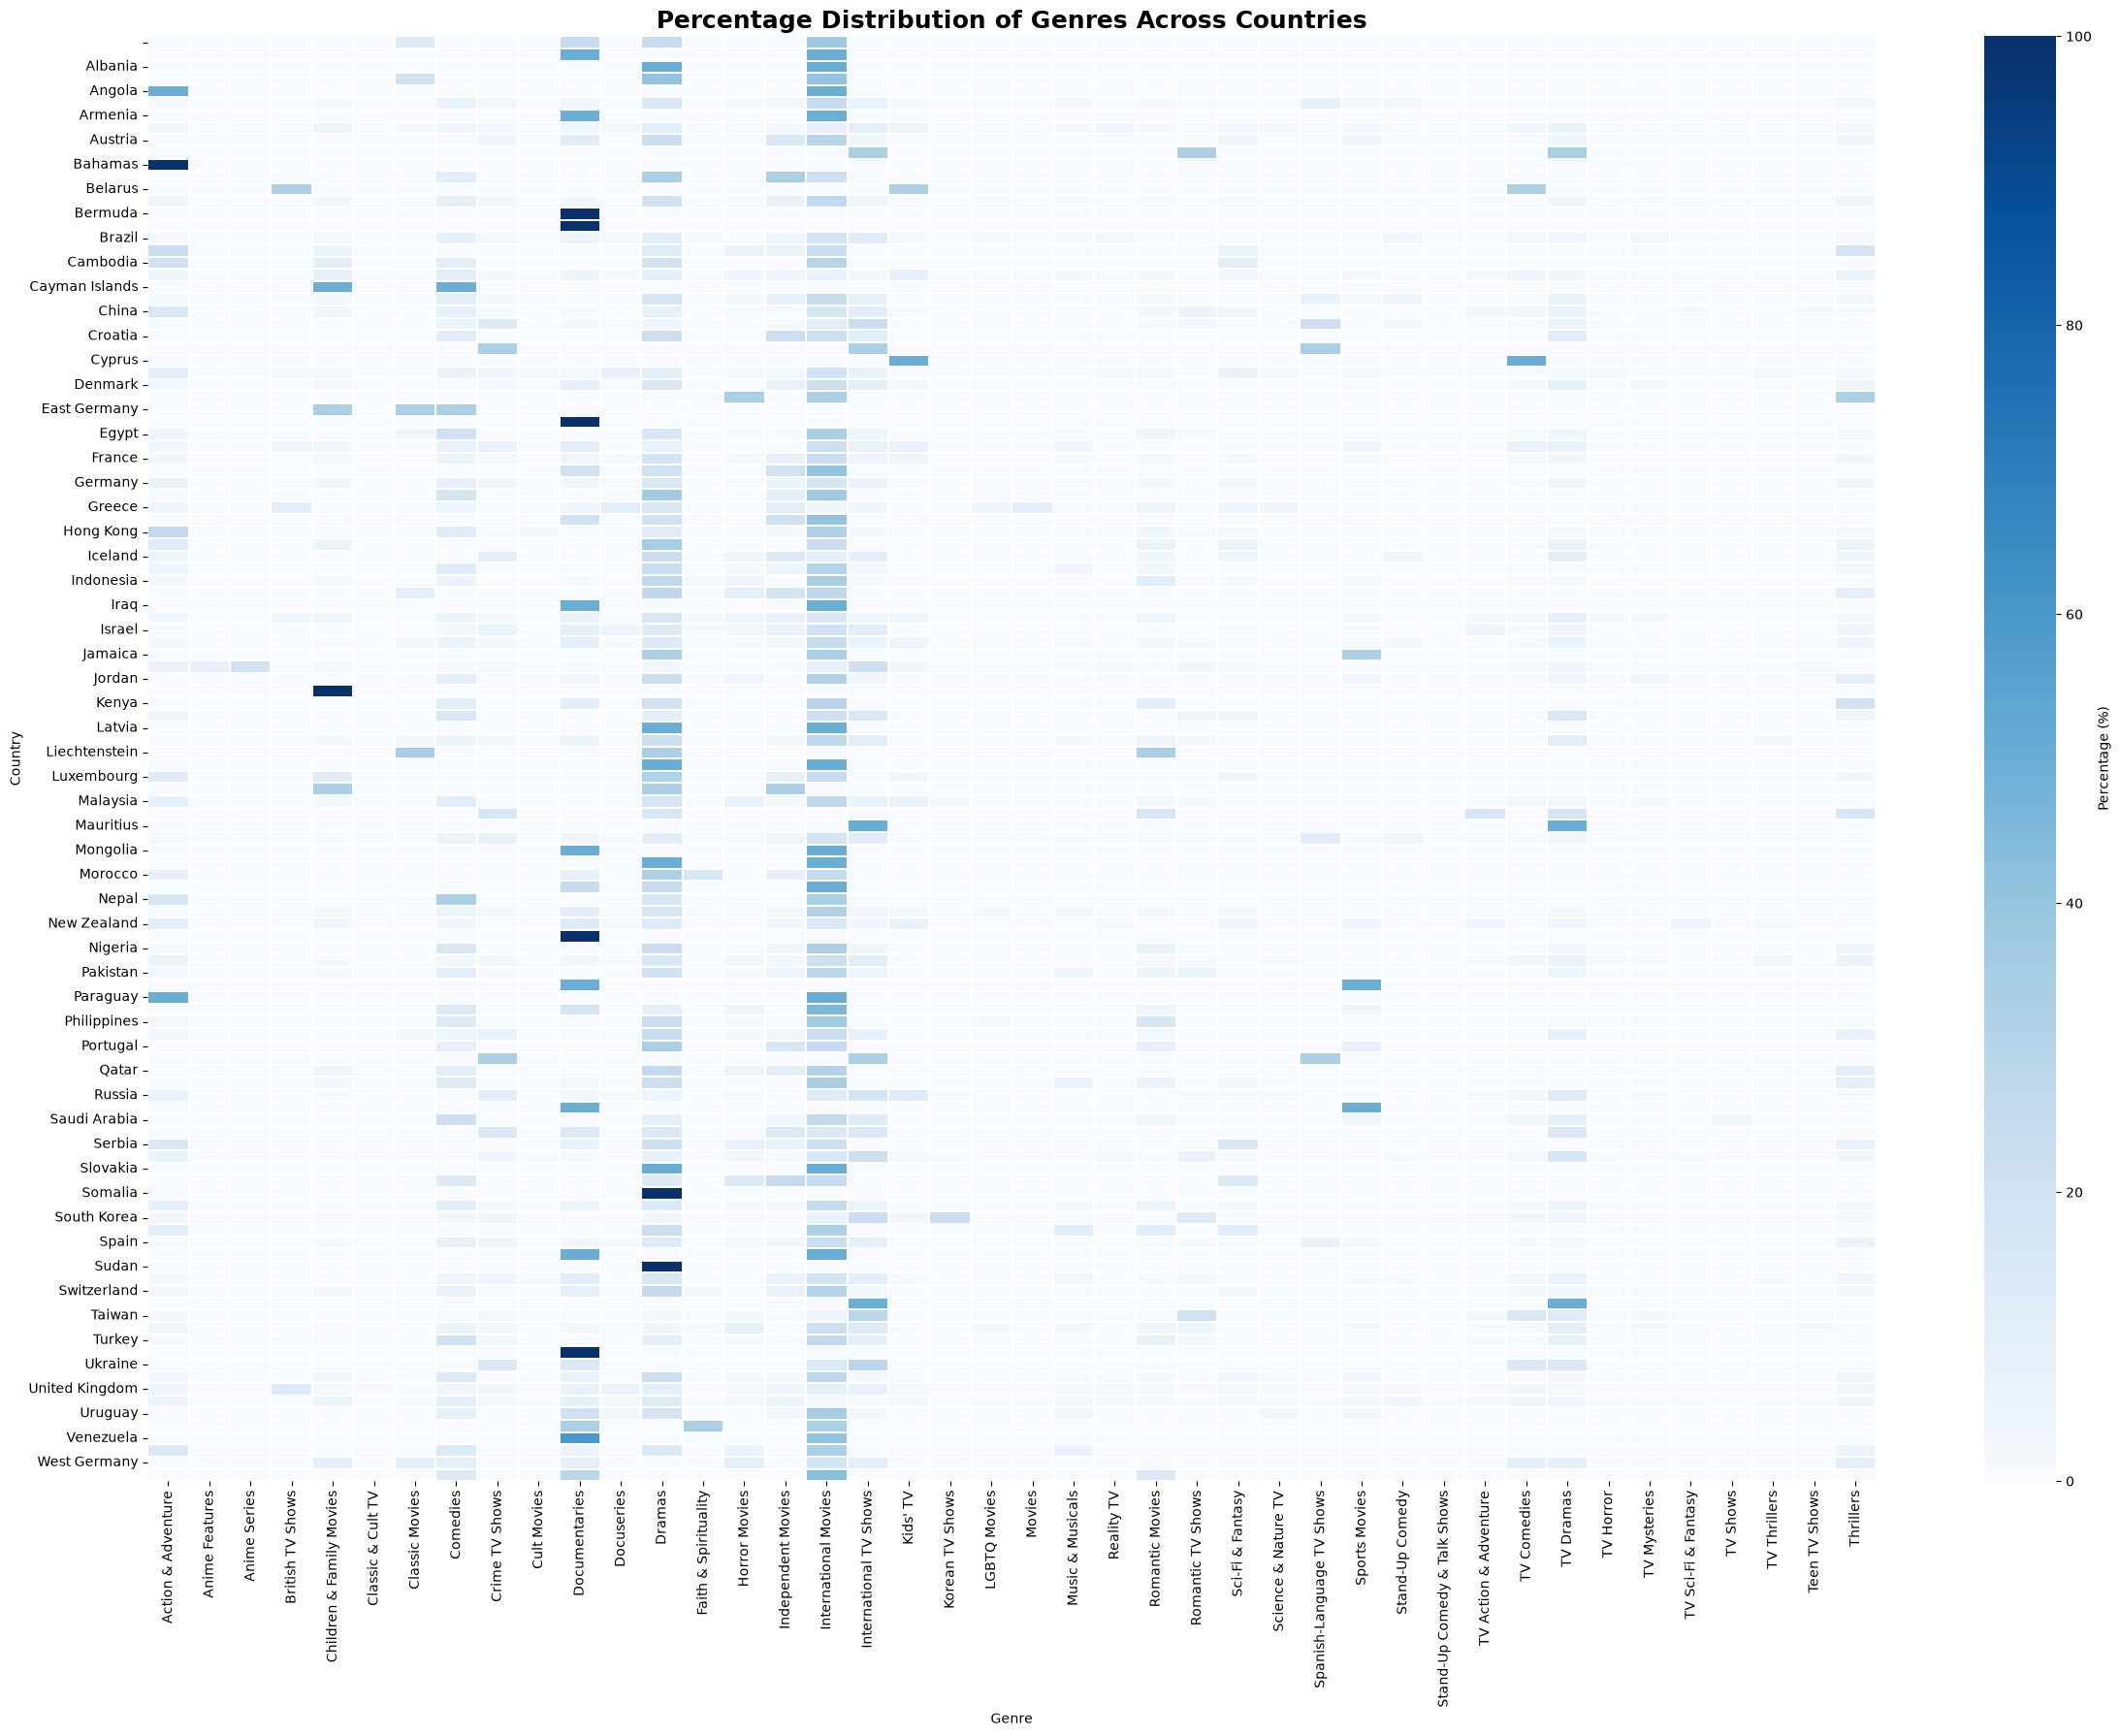

In [33]:
plt.figure(figsize=(24, 18))

sns.heatmap(
    country_genre_percentage,
    cmap="Blues",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Percentage (%)"}
)

plt.title(
    "Percentage Distribution of Genres Across Countries",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Genre")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

Since the heatmap above is difficult to address we're focusing on the top countries and top genres

In [27]:
top_countries = (
    country_genre["Country"]
    .value_counts()
    .head(10)
    .index
)

country_genre_top10 = country_genre_percentage.loc[top_countries]

country_genre_top10

Type,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Mysteries,TV Sci-Fi & Fantasy,TV Shows,TV Thrillers,Teen TV Shows,Thrillers
Country,,,,,,,,,,,,,,,,,,,,,
United States,5.23,0.07,0.25,0.35,5.77,0.30,1.14,9.75,2.29,0.70,...,1.43,3.95,3.67,0.56,0.81,0.90,0.05,0.43,0.48,4.18
India,5.04,0.00,0.00,0.08,0.83,0.00,0.41,11.58,0.34,0.19,...,0.19,0.94,0.94,0.26,0.11,0.11,0.08,0.11,0.04,3.31
United Kingdom,4.68,0.00,0.00,13.23,2.50,0.44,0.87,5.30,2.87,0.37,...,0.50,2.74,2.06,0.12,0.19,0.25,0.00,0.12,0.00,3.18
France,3.91,0.00,0.00,0.12,2.32,0.00,0.61,5.86,2.44,0.24,...,0.49,2.69,3.05,0.37,0.24,0.12,0.00,0.37,0.00,4.03
Canada,4.61,0.00,0.25,0.37,8.47,0.50,0.00,10.09,1.87,0.75,...,1.49,3.61,3.99,1.00,1.12,1.12,0.00,0.62,0.25,5.60
Japan,7.12,8.48,20.00,0.00,2.58,0.00,0.45,1.21,2.27,0.15,...,0.76,1.21,3.18,0.61,0.61,0.00,0.15,0.61,2.12,0.45
South Korea,2.74,0.00,0.00,0.00,1.54,0.00,0.00,2.74,3.94,0.17,...,1.20,2.74,4.97,0.51,0.51,0.00,0.00,0.17,0.00,2.23
Spain,0.91,0.00,0.18,0.73,1.63,0.00,0.18,7.80,4.90,0.00,...,0.54,0.91,2.00,0.00,0.00,0.00,0.00,0.00,0.18,6.72
Germany,6.00,0.00,0.00,1.11,3.78,0.00,0.00,8.44,3.56,0.44,...,0.22,1.11,4.44,0.00,0.22,0.22,0.00,0.00,0.00,4.89


In [28]:
top_genres = (
    country_genre["Type"]
    .value_counts()
    .head(10)
    .index
)

country_genre_focus = country_genre_percentage.loc[
    top_countries,
    top_genres
]

country_genre_focus

Type,International Movies,Dramas,Comedies,International TV Shows,Documentaries,Action & Adventure,Independent Movies,TV Dramas,Thrillers,Children & Family Movies
Country,,,,,,,,,,
United States,2.42,11.89,9.75,1.11,7.93,5.23,5.96,3.67,4.18,5.77
India,31.13,23.53,11.58,2.26,0.98,5.04,5.45,0.94,3.31,0.83
United Kingdom,9.30,9.73,5.30,7.24,7.42,4.68,3.87,2.06,3.18,2.50
France,23.32,17.70,5.86,4.88,5.13,3.91,7.45,3.05,4.03,2.32
Canada,6.97,8.84,10.09,2.99,5.11,4.61,4.86,3.99,5.60,8.47
Japan,9.24,2.88,1.21,21.06,1.06,7.12,0.91,3.18,0.45,2.58
South Korea,6.68,3.94,2.74,23.80,0.34,2.74,0.34,4.97,2.23,1.54
Spain,23.59,13.25,7.80,9.26,3.63,0.91,3.45,2.00,6.72,1.63
Germany,18.22,15.11,8.44,7.33,4.22,6.00,5.78,4.44,4.89,3.78


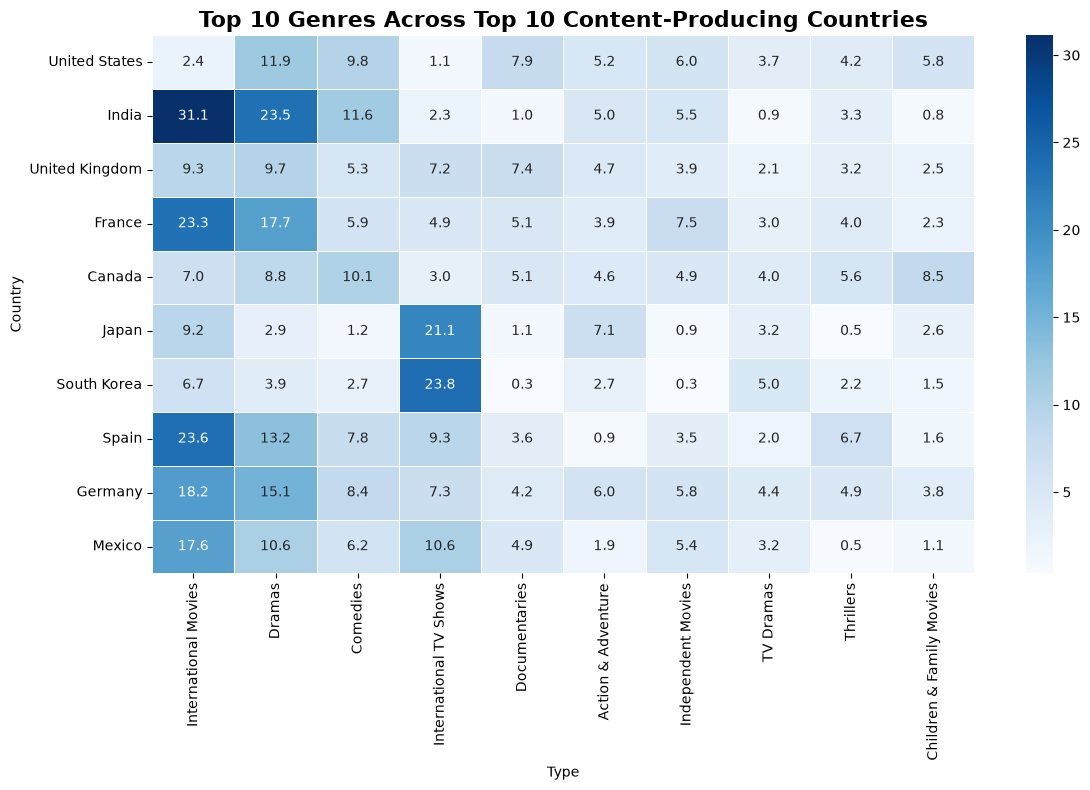

In [29]:
plot_heatmap(
    country_genre_focus,
    title="Top 10 Genres Across Top 10 Content-Producing Countries",
    cmap="Blues",
    figsize=(12,8)
)

##### Key Insights

- The analysis reveals that genre preferences vary considerably across countries, indicating that Netflix sources content according to regional production strengths and audience preferences.

- **India** exhibits the highest concentration of **International Movies (31.1%)**, followed by **Dramas (23.5%)**, highlighting the country's strong focus on film production. In contrast, **International TV Shows** contribute only **2.3%**, suggesting that Indian content on Netflix is predominantly movie-oriented.

- The **United States** demonstrates the most balanced genre distribution among the top content-producing countries. Rather than specializing in a single genre, it maintains a diverse portfolio across **Dramas (11.9%)**, **Comedies (9.8%)**, **Documentaries (7.9%)**, **Independent Movies (6.0%)**, and **Children & Family Movies (5.8%)**, reflecting the maturity and diversity of the U.S. entertainment industry.

- **Japan (21.1%)** and **South Korea (23.8%)** exhibit the highest concentration of **International TV Shows**, demonstrating their strong specialization in serialized television content. This aligns with the global popularity of Japanese anime, television dramas, and Korean dramas (K-Dramas).

- European countries such as **France (23.3%)**, **Spain (23.6%)**, **Germany (18.2%)**, and **Mexico (17.6%)** show a significant emphasis on **International Movies**, indicating that film production remains the dominant format in these regions.

- **Canada** displays one of the most balanced content portfolios after the United States, with relatively even contributions across **Comedies (10.1%)**, **Dramas (8.8%)**, **Children & Family Movies (8.5%)**, **International Movies (7.0%)**, and **Thrillers (5.6%)**.

- **Documentaries** account for a moderate proportion of content across most countries but are comparatively more represented in the **United States (7.9%)** and the **United Kingdom (7.4%)**, suggesting greater investment in factual and educational programming.

- The overall heatmap demonstrates that although Netflix offers a globally diverse catalog, content production is not uniformly distributed across genres. Each country exhibits distinct production patterns influenced by regional entertainment industries, cultural preferences, and audience demand.

- The concentration of **International Movies**, **Dramas**, and **Comedies** across nearly all top content-producing countries confirms that these genres form the foundation of Netflix's global content strategy.

##### Business Interpretation

The country-wise genre distribution highlights Netflix's strategy of combining globally popular content with regionally specialized productions. Rather than adopting a uniform acquisition strategy, Netflix leverages the strengths of different entertainment industries to create a geographically diverse content portfolio.

India's strong emphasis on film production reflects the influence of one of the world's largest movie industries, while Japan and South Korea contribute substantially to serialized television content that has gained significant international popularity. Meanwhile, the United States maintains the most diversified genre portfolio, allowing Netflix to satisfy a broad range of audience preferences across multiple content categories.

European countries such as France, Spain, and Germany continue to strengthen Netflix's catalog through internationally distributed films, supporting the platform's objective of expanding culturally diverse entertainment. Canada's balanced genre profile further contributes to the platform's content variety across both family-oriented and general entertainment genres.

Overall, the analysis demonstrates that Netflix's content acquisition strategy is geographically diversified, enabling the platform to combine regional specialization with globally appealing genres. This approach strengthens audience engagement, supports localized recommendations, and expands Netflix's presence across international markets.

##### Conclusion

The analysis confirms that specific genres are concentrated within particular countries, reflecting regional production capabilities, cultural preferences, and entertainment industry specialization. While **International Movies** dominate the catalogs of several major content-producing countries, nations such as **Japan** and **South Korea** exhibit a strong specialization in **International TV Shows**, demonstrating their leadership in serialized television production.

The **United States** maintains the most diverse genre distribution, whereas countries such as **India**, **France**, **Spain**, and **Mexico** place greater emphasis on internationally distributed films. These geographical differences illustrate Netflix's strategic approach to content sourcing by leveraging the unique strengths of individual production markets.

Overall, the relationship between countries and genres demonstrates Netflix's commitment to building a globally diverse content library that balances internationally popular genres with regionally distinctive productions. This diversified strategy enhances the platform's ability to serve audiences across different cultures, languages, and viewing preferences while strengthening its competitive position in the global streaming industry.

### Overall Summary and Findings

The Exploratory Data Analysis (EDA) of the Netflix dataset provided valuable insights into the platform's content composition, genre diversity, temporal growth, audience classification, and geographical distribution. Through a combination of univariate and bivariate analyses, the study examined both the individual characteristics of key variables and the relationships between them, enabling a comprehensive understanding of Netflix's global content library.

#### Summary of Findings

##### Content Distribution

- Movies dominate Netflix's catalog, accounting for **69.14%** of all available titles, while **TV Shows** represent **30.86%**.
- The platform maintains a movie-oriented catalog while continuing to invest in television series to promote long-term viewer engagement.

##### Genre Distribution

- **International Movies**, **Dramas**, and **Comedies** are the most prevalent genres within Netflix's library.
- The strong presence of internationally produced content highlights Netflix's commitment to serving a diverse global audience.
- The genre distribution indicates a well-balanced content portfolio that caters to viewers with different entertainment preferences.

##### Content Growth Over Time

- Netflix experienced rapid expansion between **2015 and 2019**, with **2019** recording the highest number of content releases.
- Although a slight decline is observed in **2020**, the platform maintained a high release volume.
- The lower number of titles in **2021** is likely influenced by the dataset's coverage period rather than a significant reduction in content production.

##### Country-wise Content Distribution

- The **United States** is the largest contributor to Netflix's catalog, followed by **India** and the **United Kingdom**.
- Several other countries, including **Canada**, **France**, **Japan**, **Spain**, and **South Korea**, make substantial contributions, reflecting Netflix's globally diversified content acquisition strategy.
- The analysis confirms that Netflix sources content from a broad range of geographical regions to maximize international audience reach.

##### Relationship Between Genres and Content Ratings

- **TV-MA** and **TV-14** are the dominant maturity ratings across the majority of Netflix genres.
- Mature-oriented genres such as **Dramas**, **International Movies**, **Crime TV Shows**, and **TV Dramas** primarily target adult audiences.
- **Children & Family Movies** consistently receive family-friendly ratings such as **G**, **PG**, **TV-Y**, and **TV-Y7**, demonstrating effective audience segmentation and content classification.

##### Relationship Between Countries and Genres

- Genre preferences vary significantly across countries, indicating regional specialization in content production.
- **India** primarily contributes **International Movies**, highlighting its strong film production industry.
- **Japan** and **South Korea** exhibit the highest concentration of **International TV Shows**, reflecting their global reputation for serialized television content.
- The **United States** maintains the most diversified genre portfolio, contributing consistently across multiple genres including dramas, comedies, documentaries, children's programming, and independent films.
- European countries such as **France**, **Spain**, and **Germany** also demonstrate strong emphasis on internationally distributed films.

#### Overall Findings

The analysis demonstrates that Netflix has developed a highly diversified content ecosystem supported by strategic investments in international productions, mature storytelling, and region-specific entertainment. While movies remain the dominant content format, the platform maintains a balanced catalog that spans numerous genres, audience categories, and geographical regions.

The relationship between genres, maturity ratings, and countries of production illustrates Netflix's data-driven content strategy. Rather than adopting a uniform global approach, Netflix leverages the production strengths of different countries while aligning content ratings with audience expectations. This combination of global diversity and regional specialization enables the platform to appeal to viewers across different cultures, languages, and demographic groups.

Overall, the findings indicate that Netflix's content acquisition and distribution strategy successfully balances internationally popular entertainment with localized productions, strengthening its position as one of the world's leading streaming platforms.

#### Conclusion

The Exploratory Data Analysis successfully addressed all six investigation questions by examining both the individual characteristics of the dataset and the relationships between key variables. The study revealed important insights into Netflix's content composition, growth trends, audience targeting strategy, and geographical content distribution.

The results demonstrate that Netflix's success is supported by a globally diversified content portfolio, effective content classification practices, and strategic investments in regional entertainment industries. These insights provide a strong analytical foundation for future research, predictive modeling, recommendation system development, and business decision-making within the digital streaming industry.